# Orquestrador v5 — Comparacao Justa com Tuning

Todos os solvers sao primeiro calibrados
com Optuna na instancia alvo (16x5) e depois comparados em todas as instancias
com o mesmo orcamento computacional (~5.000 avaliacoes cada).

**Solvers:** ACO | BRKGA (3 variantes) | Neuro-BOA | PBIL-Fuzzy
**Engine:** FlowShopEngine oficial | **Modo:** NPFS | **Objetivo:** Makespan


## 0. Clonar o repositorio


In [1]:
REPO_URL = "https://github.com/EuRonald123/FlowShop_S.git"
DESTINO = "/content/FlowShop_S"
!rm -rf {DESTINO}
!git clone {REPO_URL} {DESTINO}
%cd {DESTINO}
import os
ROOT = os.getcwd()
print(f"Diretorio: {ROOT}")


Cloning into '/content/FlowShop_S'...
remote: Enumerating objects: 478, done.
remote: Counting objects: 100% (478/478), done.
remote: Compressing objects: 100% (461/461), done.
remote: Total 478 (delta 16), reused 472 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (478/478), 1.54 MiB | 7.48 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/FlowShop_S
Diretorio: /content/FlowShop_S


## 1. Setup — Instalacao e Imports


In [2]:
!pip install -q pymoo scikit-fuzzy optuna numpy matplotlib pandas scipy
try:
    import torch
except ImportError:
    !pip install -q torch --index-url https://download.pytorch.org/whl/cpu
    import torch
print("Dependencias instaladas.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.2/347.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.6 MB/s eta 0:00:00
Dependencias instaladas.


In [3]:
import sys, time, copy, random
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('default')

sys.path.insert(0, ROOT)
from src.flowshop_engine import FlowShopEngine
from src.solvers.adapter import (
    rodar_experimento, rodar_aco, rodar_brkga,
    rodar_neuro_boa, rodar_pbil_fuzzy, SolverResult, listar_solvers_disponiveis,
)
from src.solvers.brkga_solver import rodar_optuna as rodar_optuna_brkga
from src.solvers.pbil_fuzzy_solver import PBILFuzzySolver
import optuna
print("Imports concluidos.")


Imports concluidos.


## 2. Dados


In [4]:
DATA_DIR = Path(ROOT) / "data" / "Small"
if not DATA_DIR.exists() or len(list(DATA_DIR.glob("*.txt"))) == 0:
    zip_path = Path(ROOT) / "data" / "Small.zip"
    if zip_path.exists():
        import zipfile
        with zipfile.ZipFile(str(zip_path), "r") as z:
            z.extractall(str(Path(ROOT) / "data"))
        print(f"Extraido para {DATA_DIR}")
    else:
        print("AVISO: data/Small vazio")
else:
    print(f"Instancias: {len(list(DATA_DIR.glob('*.txt')))} arquivos")


Instancias: 420 arquivos


## 3. Configuracao Geral


In [5]:
RESULTADOS_DIR = Path(ROOT) / "resultados_comparacao_v5"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

# Instancias
INSTANCIAS_CONFIG = [
    {"rotulo": "4x2",  "padrao": "I_2_4_",   "desc": "4 jobs, 2 maq."},
    {"rotulo": "16x2", "padrao": "I_2_16_2_", "desc": "16 jobs, 2 maq."},
    {"rotulo": "16x5", "padrao": "I_2_16_5_", "desc": "16 jobs, 5 maq. (alvo)"},
    {"rotulo": "16x4", "padrao": "I_4_16_5_", "desc": "16 jobs, 4 maq."},
]
OBJECTIVE = "Makespan"


## 4. Selecao de Instancias


In [6]:
def selecionar_instancias(data_dir, configs):
    todos = sorted(data_dir.glob("*.txt"))
    if not todos:
        raise FileNotFoundError(f"Nenhum .txt em {data_dir}")
    escolhidas = {}
    for cfg in configs:
        cand = [f for f in todos if cfg["padrao"] in f.name]
        if not cand:
            continue
        escolhidas[cfg["rotulo"]] = cand[0]
        print(f"{cfg['rotulo']}: {cand[0].name}")
    return escolhidas

instancias = selecionar_instancias(DATA_DIR, INSTANCIAS_CONFIG)


4x2: I_2_4_2_1.txt
16x2: I_2_16_2_1.txt
16x5: I_2_16_5_1.txt
16x4: I_4_16_5_1.txt


## 5. Tuning com Optuna

Cada solver e calibrado na instancia alvo (16x5) com 15-20 trials.
O PBIL-Fuzzy tambem recebe Optuna, mantendo a comparacao justa.


In [7]:
# Carrega a instancia alvo para usar em todos os tunings
inst_alvo = instancias["16x5"]
nj, nm, pt, dd = FlowShopEngine.carregar_instancia_txt(str(inst_alvo))
engine_alvo = FlowShopEngine(nj, nm, pt, dd)
print(f"Engine 16x5: {nj} jobs, {nm} maquinas")

SEEDS_TUNING = (1, 2, 3)  # 3 seeds por trial do Optuna


Engine 16x5: 16 jobs, 5 maquinas


In [8]:
# TUNING ACO: 15 trials, 50 iteracoes cada (rapido)

def objetivo_aco(trial):
    params = {
        "alpha": trial.suggest_float("alpha", 0.1, 5.0),
        "beta": trial.suggest_float("beta", 0.1, 5.0),
        "rho": trial.suggest_float("rho", 0.01, 0.9),
        "Q": trial.suggest_float("Q", 1.0, 500.0),
        "n_ants": trial.suggest_int("n_ants", 5, 50),
    }
    custos = []
    for sd in SEEDS_TUNING:
        r = rodar_aco(engine_alvo, seed=sd, mode="NPFS",
                      n_ants=params["n_ants"], n_iterations=50,
                      alpha=params["alpha"], beta=params["beta"],
                      rho=params["rho"], Q=params["Q"])
        custos.append(r.best_cost)
    return float(np.mean(custos))

print("Tuning ACO...")
study_aco = optuna.create_study(direction="minimize")
study_aco.optimize(objetivo_aco, n_trials=15)
params_aco = study_aco.best_params
print(f"  Melhor ACO: {params_aco}")
print(f"  Custo: {study_aco.best_value:.2f}")


[I 2026-09-24 00:21:32,088] A new study created in memory with name: no-name-9ea2ff6f-de01-49d0-a009-1eaf3bfb8aba


Tuning ACO...


[I 2026-09-24 00:21:50,221] Trial 0 finished with value: 2610.0 and parameters: {'alpha': 3.9133849488041457, 'beta': 3.911469668290514, 'rho': 0.2888908913467046, 'Q': 455.93569011640864, 'n_ants': 21}. Best is trial 0 with value: 2610.0.
[I 2026-09-24 00:22:02,592] Trial 1 finished with value: 2887.6666666666665 and parameters: {'alpha': 2.4996524865466796, 'beta': 1.5304582945508196, 'rho': 0.8300648083523327, 'Q': 200.94150110476951, 'n_ants': 21}. Best is trial 0 with value: 2610.0.
[I 2026-09-24 00:22:21,177] Trial 2 finished with value: 2697.3333333333335 and parameters: {'alpha': 3.8284933047078002, 'beta': 4.688069213228695, 'rho': 0.38178098126481846, 'Q': 178.09382112878964, 'n_ants': 36}. Best is trial 0 with value: 2610.0.
[I 2026-09-24 00:22:26,701] Trial 3 finished with value: 2844.3333333333335 and parameters: {'alpha': 4.7954172983928, 'beta': 1.8619389495401601, 'rho': 0.8392712519054372, 'Q': 78.07519006421248, 'n_ants': 10}. Best is trial 0 with value: 2610.0.
[I 20

  Melhor ACO: {'alpha': 4.809134091832226, 'beta': 3.3541528425966036, 'rho': 0.7288274924876164, 'Q': 450.8337812468469, 'n_ants': 30}
  Custo: 2577.33


In [9]:
# TUNING BRKGA: usa a funcao rodar_optuna do brkga_solver
# (15 trials, 3 seeds, 100 geracoes cada trial)

print("Tuning BRKGA...")
study_brkga, melhor_config_brkga = rodar_optuna_brkga(
    engine_alvo, pop_size=100, n_gen=100,
    seeds=SEEDS_TUNING, n_trials=15, seed_optuna=0,
)
print(f"  Melhor BRKGA: {melhor_config_brkga}")
print(f"  Custo: {study_brkga.best_value:.2f}")


[I 2026-09-24 00:26:02,968] A new study created in memory with name: no-name-bcb5c8c8-6917-4582-beef-0b8112b0d5f1


Tuning BRKGA...


[I 2026-09-24 00:26:10,503] Trial 0 finished with value: 1546.0 and parameters: {'frac_elites': 0.24208472637456369, 'frac_mutantes': 0.30031627823034684, 'bias': 0.6712435192322397}. Best is trial 0 with value: 1546.0.
[I 2026-09-24 00:26:16,776] Trial 1 finished with value: 1446.6666666666667 and parameters: {'frac_elites': 0.24070911404891393, 'frac_mutantes': 0.19827917976861664, 'bias': 0.6906523508799953}. Best is trial 1 with value: 1446.6666666666667.
[I 2026-09-24 00:26:24,556] Trial 2 finished with value: 1536.3333333333333 and parameters: {'frac_elites': 0.20315552394194242, 'frac_mutantes': 0.3621205502737279, 'bias': 0.8336482422254632}. Best is trial 1 with value: 1446.6666666666667.
[I 2026-09-24 00:26:31,135] Trial 3 finished with value: 1557.6666666666667 and parameters: {'frac_elites': 0.18420453158902222, 'frac_mutantes': 0.3271037633289326, 'bias': 0.638002713888807}. Best is trial 1 with value: 1446.6666666666667.
[I 2026-09-24 00:26:38,555] Trial 4 finished with v

  Melhor BRKGA: {'n_elites': 8, 'n_offsprings': 86, 'n_mutants': 6, 'bias': 0.7746789304965721}
  Custo: 1354.33


In [10]:
# TUNING Neuro-BOA: 10 trials, 30 geracoes cada trial (mais rapido)
# O Neuro-BOA usa o decoder proprio, entao precisa de Instance

from src.solvers.neuro_boa_solver import (
    Instance, run_method, ConfigNeuroBOA, decode_npfs,
)

inst_alvo_nb = Instance(
    name="16x5", group="Small", n_jobs=nj, n_machines=nm,
    processing=pt.copy(), due_dates=dd.copy(),
)

def objetivo_neuro(trial):
    cfg = ConfigNeuroBOA(
        population_size=trial.suggest_categorical("pop", [30, 40, 60]),
        generations=30,
        elite_frac=trial.suggest_float("elite_frac", 0.10, 0.25),
        neuro_hidden=trial.suggest_categorical("neuro_hidden", [64, 128, 256]),
        neuro_epochs_per_gen=trial.suggest_int("epochs", 1, 3),
        neuro_temperature=trial.suggest_float("temp", 0.5, 1.8),
        dropout=trial.suggest_float("dropout", 0.0, 0.25),
        bayes_smoothing=trial.suggest_float("smoothing", 0.1, 3.0, log=True),
        quality_fraction=trial.suggest_float("q_frac", 0.60, 0.90),
        selector_epsilon=trial.suggest_float("eps", 0.05, 0.20),
        selector_hidden=trial.suggest_categorical("sel_hidden", [16, 32, 64]),
        probe_per_generator=2, diverse_candidate_frac=0.35, diverse_frac=0.20, neuro_lr=1e-3, selector_lr=1e-3,
    )
    custos = []
    for k, sd in enumerate(SEEDS_TUNING):
        r = run_method(inst_alvo_nb, cfg, mode="adaptativo", seed=1000+k, verbose=False)
        custos.append(r["best_makespan"])
    return float(np.mean(custos))

print("Tuning Neuro-BOA (10 trials, ~30 gen cada)...")
study_neuro = optuna.create_study(direction="minimize")
study_neuro.optimize(objetivo_neuro, n_trials=15)
params_neuro = study_neuro.best_params
print(f"  Melhor Neuro-BOA: {params_neuro}")
print(f"  Custo: {study_neuro.best_value:.2f}")


[I 2026-09-24 00:27:55,584] A new study created in memory with name: no-name-8db86ccb-2155-430a-b431-aa201fd70a64


Tuning Neuro-BOA (10 trials, ~30 gen cada)...


[I 2026-09-24 00:29:15,613] Trial 0 finished with value: 2261.0 and parameters: {'pop': 60, 'elite_frac': 0.19271403055744177, 'neuro_hidden': 256, 'epochs': 1, 'temp': 1.130197880955176, 'dropout': 0.2169305667432215, 'smoothing': 0.13150798518759166, 'q_frac': 0.7783846307224211, 'eps': 0.06956998679222919, 'sel_hidden': 64}. Best is trial 0 with value: 2261.0.
[I 2026-09-24 00:30:30,344] Trial 1 finished with value: 2232.3333333333335 and parameters: {'pop': 60, 'elite_frac': 0.1932411727731309, 'neuro_hidden': 128, 'epochs': 3, 'temp': 0.5372609534608025, 'dropout': 0.16539419484206533, 'smoothing': 0.7515551046883506, 'q_frac': 0.7291146744290995, 'eps': 0.10677134907932985, 'sel_hidden': 16}. Best is trial 1 with value: 2232.3333333333335.
[I 2026-09-24 00:31:49,060] Trial 2 finished with value: 2216.0 and parameters: {'pop': 60, 'elite_frac': 0.21568978116232415, 'neuro_hidden': 256, 'epochs': 3, 'temp': 1.0891457443746202, 'dropout': 0.010566439735348016, 'smoothing': 0.2267315

  Melhor Neuro-BOA: {'pop': 60, 'elite_frac': 0.15439687735967175, 'neuro_hidden': 256, 'epochs': 3, 'temp': 0.5880056407723188, 'dropout': 0.01912759130242106, 'smoothing': 2.3886079824299347, 'q_frac': 0.7193941551954974, 'eps': 0.17875719568732273, 'sel_hidden': 32}
  Custo: 2027.33


In [11]:
# TUNING PBIL-Fuzzy: 15 trials, 50 geracoes cada

def objetivo_pbil(trial):
    n_pop = trial.suggest_int("n_pop", 40, 120)
    sigma = trial.suggest_float("sigma", 0.05, 0.30)
    pct_elite = trial.suggest_float("pct_elite", 0.05, 0.15)
    pct_sub = trial.suggest_float("pct_subelite", 0.20, 0.50)
    delta = trial.suggest_float("delta", 0.10, 0.40)
    custos = []
    for sd in SEEDS_TUNING:
        r = rodar_pbil_fuzzy(engine_alvo, seed=sd, n_pop=n_pop,
                            sigma_amostragem=sigma, pct_elite=pct_elite,
                            pct_subelite=pct_sub, delta=delta,
                            max_geracoes=50)
        custos.append(r.best_cost)
    return float(np.mean(custos))

print("Tuning PBIL-Fuzzy...")
study_pbil = optuna.create_study(direction="minimize")
study_pbil.optimize(objetivo_pbil, n_trials=15)
params_pbil = study_pbil.best_params
print(f"  Melhor PBIL: {params_pbil}")
print(f"  Custo: {study_pbil.best_value:.2f}")


[I 2026-09-24 00:45:05,669] A new study created in memory with name: no-name-d1b785f1-872f-4b89-a30d-fcac277998eb


Tuning PBIL-Fuzzy...


[I 2026-09-24 00:45:07,300] Trial 0 finished with value: 1994.3333333333333 and parameters: {'n_pop': 59, 'sigma': 0.06851780912416854, 'pct_elite': 0.13973141838843722, 'pct_subelite': 0.2122413246163858, 'delta': 0.3324521955509405}. Best is trial 0 with value: 1994.3333333333333.
[I 2026-09-24 00:45:09,417] Trial 1 finished with value: 1902.0 and parameters: {'n_pop': 80, 'sigma': 0.18279929252422017, 'pct_elite': 0.09967791444552912, 'pct_subelite': 0.4177202248269566, 'delta': 0.31269391671783553}. Best is trial 1 with value: 1902.0.
[I 2026-09-24 00:45:11,070] Trial 2 finished with value: 1933.6666666666667 and parameters: {'n_pop': 61, 'sigma': 0.283776143656214, 'pct_elite': 0.062103379490806, 'pct_subelite': 0.35300084745179294, 'delta': 0.1194139538785626}. Best is trial 1 with value: 1902.0.
[I 2026-09-24 00:45:12,459] Trial 3 finished with value: 2017.6666666666667 and parameters: {'n_pop': 50, 'sigma': 0.28753778970879973, 'pct_elite': 0.09430043706233299, 'pct_subelite': 

  Melhor PBIL: {'n_pop': 92, 'sigma': 0.061801350096562985, 'pct_elite': 0.0676033844512636, 'pct_subelite': 0.4290519471526442, 'delta': 0.3648219450611037}
  Custo: 1763.33


In [12]:
# RESUMO DOS PARAMETROS ENCONTRADOS

print("=" * 60)
print("RESUMO DO TUNING — Instancia 16x5")
print("=" * 60)

print(f"\nACO: {params_aco}")
print(f"BRKGA: {melhor_config_brkga}")
print(f"Neuro-BOA: {params_neuro}")
print(f"PBIL-Fuzzy: {params_pbil}")


RESUMO DO TUNING — Instancia 16x5

ACO: {'alpha': 4.809134091832226, 'beta': 3.3541528425966036, 'rho': 0.7288274924876164, 'Q': 450.8337812468469, 'n_ants': 30}
BRKGA: {'n_elites': 8, 'n_offsprings': 86, 'n_mutants': 6, 'bias': 0.7746789304965721}
Neuro-BOA: {'pop': 60, 'elite_frac': 0.15439687735967175, 'neuro_hidden': 256, 'epochs': 3, 'temp': 0.5880056407723188, 'dropout': 0.01912759130242106, 'smoothing': 2.3886079824299347, 'q_frac': 0.7193941551954974, 'eps': 0.17875719568732273, 'sel_hidden': 32}
PBIL-Fuzzy: {'n_pop': 92, 'sigma': 0.061801350096562985, 'pct_elite': 0.0676033844512636, 'pct_subelite': 0.4290519471526442, 'delta': 0.3648219450611037}


## 6. Funcao para rodar um solver em todas as instancias

Recebe uma funcao que cria os parametros e retorna DataFrame com resultados.


In [13]:
def rodar_solver_em_todas_instancias(
    rotulo, versao, fn_executar, instancias_dict, n_seeds=5, seed_inicio=100,
):
    """
    Roda um solver em todas as instancias.
    fn_executar(engine, seed) deve retornar SolverResult.
    """
    linhas = []
    detalhes = {}
    for rot_inst, inst_path in instancias_dict.items():
        nj, nm, pt, dd = FlowShopEngine.carregar_instancia_txt(str(inst_path))
        eng = FlowShopEngine(nj, nm, pt, dd)
        for seed in range(seed_inicio, seed_inicio + n_seeds):
            try:
                r = fn_executar(eng, seed)
                linhas.append({
                    "instancia": rot_inst, "solver": rotulo,
                    "versao": versao, "seed": seed,
                    "makespan": r.best_cost,
                    "tardiness": r.tardiness,
                    "gap_pct": round(r.gap_percent(), 2),
                    "tempo_s": round(r.time_seconds, 2),
                    "n_avaliacoes": r.n_evaluations,
                })
                detalhes[(rot_inst, seed)] = r
            except Exception as e:
                print(f"    ERRO {rot_inst} seed {seed}: {e}")
    return pd.DataFrame(linhas), detalhes


## 7. Comparacao Padronizada

Todos os solvers com ~5.000 avaliacoes cada, usando os parametros
encontrados pelo Optuna na secao anterior.


In [14]:
# ACO com params do Optuna, 50 formigas x 100 iter = 5000 avaliacoes

def run_aco_tunado(eng, seed):
    return rodar_aco(eng, seed=seed, mode="NPFS",
                    n_ants=params_aco["n_ants"], n_iterations=100,
                    alpha=params_aco["alpha"], beta=params_aco["beta"],
                    rho=params_aco["rho"], Q=params_aco["Q"])

print("Rodando ACO tunado...")
df_aco, det_aco = rodar_solver_em_todas_instancias(
    "ACO", "tunado", run_aco_tunado, instancias)


Rodando ACO tunado...


In [15]:
# BRKGA 3 versoes, 100 pop x 50 gen = 5000 avaliacoes

config_optuna = melhor_config_brkga.copy()
config_optuna["n_gen"] = 50

def run_brkga_default(eng, seed):
    return rodar_brkga(eng, seed=seed, n_gen=50, version="fixo_default",
                       n_elites=20, n_offsprings=70, n_mutants=10, bias=0.7)

def run_brkga_optuna(eng, seed):
    return rodar_brkga(eng, seed=seed, n_gen=50, version="fixo_optuna",
                       **{k: v for k, v in config_optuna.items() if k != "n_gen"})

def run_brkga_fuzzy(eng, seed):
    return rodar_brkga(eng, seed=seed, n_gen=50, version="fuzzy",
                       **{k: v for k, v in config_optuna.items() if k != "n_gen"})

print("Rodando BRKGA fixo_default...")
df_brkga_def, det_brkga_def = rodar_solver_em_todas_instancias(
    "BRKGA", "fixo_default", run_brkga_default, instancias)

print("Rodando BRKGA fixo_optuna...")
df_brkga_opt, det_brkga_opt = rodar_solver_em_todas_instancias(
    "BRKGA", "fixo_optuna", run_brkga_optuna, instancias)

print("Rodando BRKGA fuzzy...")
df_brkga_fuz, det_brkga_fuz = rodar_solver_em_todas_instancias(
    "BRKGA", "fuzzy", run_brkga_fuzzy, instancias)


Rodando BRKGA fixo_default...
Rodando BRKGA fixo_optuna...
Rodando BRKGA fuzzy...


In [16]:
# Neuro-BOA com params do Optuna, 50 pop x 100 gen = 5000 avaliacoes

cfg_neuro_v5 = ConfigNeuroBOA(
    population_size=params_neuro["pop"], generations=100,
    elite_frac=params_neuro["elite_frac"],
    diverse_candidate_frac=0.35, diverse_frac=0.20,
    neuro_hidden=params_neuro["neuro_hidden"], neuro_lr=1e-3,
    neuro_epochs_per_gen=params_neuro["epochs"],
    neuro_temperature=params_neuro["temp"],
    dropout=params_neuro["dropout"],
    bayes_smoothing=params_neuro["smoothing"],
    quality_fraction=params_neuro["q_frac"],
    probe_per_generator=2,
    selector_epsilon=params_neuro["eps"],
    selector_hidden=params_neuro["sel_hidden"],
    selector_lr=1e-3,
)

def run_neuro_tunado(eng, seed):
    return rodar_neuro_boa(eng, seed=seed, mode="adaptativo",
                           population_size=cfg_neuro_v5.population_size,
                           generations=cfg_neuro_v5.generations,
                           elite_frac=cfg_neuro_v5.elite_frac,
                           neuro_hidden=cfg_neuro_v5.neuro_hidden,
                           neuro_epochs_per_gen=cfg_neuro_v5.neuro_epochs_per_gen,
                           neuro_temperature=cfg_neuro_v5.neuro_temperature,
                           dropout=cfg_neuro_v5.dropout,
                           bayes_smoothing=cfg_neuro_v5.bayes_smoothing,
                           quality_fraction=cfg_neuro_v5.quality_fraction,
                           probe_per_generator=cfg_neuro_v5.probe_per_generator,
                           selector_epsilon=cfg_neuro_v5.selector_epsilon,
                           selector_hidden=cfg_neuro_v5.selector_hidden)

print("Rodando Neuro-BOA tunado...")
df_neuro, det_neuro = rodar_solver_em_todas_instancias(
    "Neuro-BOA", "adaptativo", run_neuro_tunado, instancias)


Rodando Neuro-BOA tunado...


In [17]:
# PBIL-Fuzzy com params do Optuna, 80 pop x 62 gen = 4960 (~5000) avaliacoes

pbil_n_pop = params_pbil["n_pop"]
# Ajusta geracoes para ~5000 avaliacoes
pbil_max_gen = max(30, int(round(5000 / pbil_n_pop)))

def run_pbil_tunado(eng, seed):
    return rodar_pbil_fuzzy(eng, seed=seed,
                           n_pop=pbil_n_pop,
                           sigma_amostragem=params_pbil["sigma"],
                           pct_elite=params_pbil["pct_elite"],
                           pct_subelite=params_pbil["pct_subelite"],
                           delta=params_pbil["delta"],
                           max_geracoes=pbil_max_gen)

print(f"Rodando PBIL-Fuzzy tunado (n_pop={pbil_n_pop}, gen={pbil_max_gen})...")
df_pbil, det_pbil = rodar_solver_em_todas_instancias(
    "PBIL-Fuzzy", "tunado", run_pbil_tunado, instancias)


Rodando PBIL-Fuzzy tunado (n_pop=92, gen=54)...


In [18]:
# Consolida todos os resultados num DataFrame unico
df_v5 = pd.concat([df_aco, df_brkga_def, df_brkga_opt, df_brkga_fuz,
                    df_neuro, df_pbil], ignore_index=True)
csv_path = RESULTADOS_DIR / "resultados_v5.csv"
df_v5.to_csv(csv_path, index=False)
print(f"Resultados salvos em: {csv_path}")
print(f"Total: {len(df_v5)} linhas")


Resultados salvos em: /content/FlowShop_S/resultados_comparacao_v5/resultados_v5.csv
Total: 120 linhas


## 8. Tabela Comparativa


In [19]:
def gerar_tabela_v5(df):
    agrupado = df.groupby(["instancia", "solver", "versao"], dropna=False)
    linhas = []
    for (inst, sol, ver), grp in agrupado:
        mk = grp["makespan"].dropna()
        if len(mk) == 0:
            continue
        sol_ver = f"{sol} ({ver})"
        linhas.append({
            "Instancia": inst, "Solver": sol_ver,
            "Makespan": f"{mk.mean():.1f} +- {mk.std():.1f}",
            "Melhor": f"{mk.min():.1f}",
            "Tardiness": f"{grp['tardiness'].mean():.1f}",
            "Tempo(s)": f"{grp['tempo_s'].mean():.2f}",
            "Gap(%)": f"{grp['gap_pct'].mean():.2f}",
        })
    return pd.DataFrame(linhas)

print("=" * 120)
print("COMPARACAO PADRONIZADA (~5000 avaliacoes cada)")
print("=" * 120)
tabela_v5 = gerar_tabela_v5(df_v5)
print(tabela_v5.to_string(index=False))


COMPARACAO PADRONIZADA (~5000 avaliacoes cada)
Instancia                 Solver        Makespan Melhor Tardiness Tempo(s) Gap(%)
     16x2           ACO (tunado)  1458.2 +- 59.8 1413.0   12155.6     4.30  69.17
     16x2   BRKGA (fixo_default)  1019.8 +- 23.1  996.0    8351.4     0.87  18.31
     16x2    BRKGA (fixo_optuna)  1022.4 +- 24.9  987.0    8289.8     0.99  18.61
     16x2          BRKGA (fuzzy)  1012.8 +- 16.3  996.0    8310.4     1.87  17.50
     16x2 Neuro-BOA (adaptativo)  1009.4 +- 10.7  996.0    7026.0    37.58  17.10
     16x2    PBIL-Fuzzy (tunado)  1032.8 +- 29.7  988.0    8706.6     0.44  19.81
     16x4           ACO (tunado) 3000.2 +- 209.0 2784.0   36775.8    10.69 292.18
     16x4   BRKGA (fixo_default)  1653.0 +- 35.7 1605.0   17368.6     1.06 116.08
     16x4    BRKGA (fixo_optuna)  1581.0 +- 39.3 1535.0   15877.2     1.25 106.67
     16x4          BRKGA (fuzzy)  1585.8 +- 45.5 1509.0   16207.0     2.72 107.29
     16x4 Neuro-BOA (adaptativo) 1679.2 +- 549.0 11

## 9. Graficos


/tmp/ipykernel_910/2695913959.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=solvers_unicos, patch_artist=True)


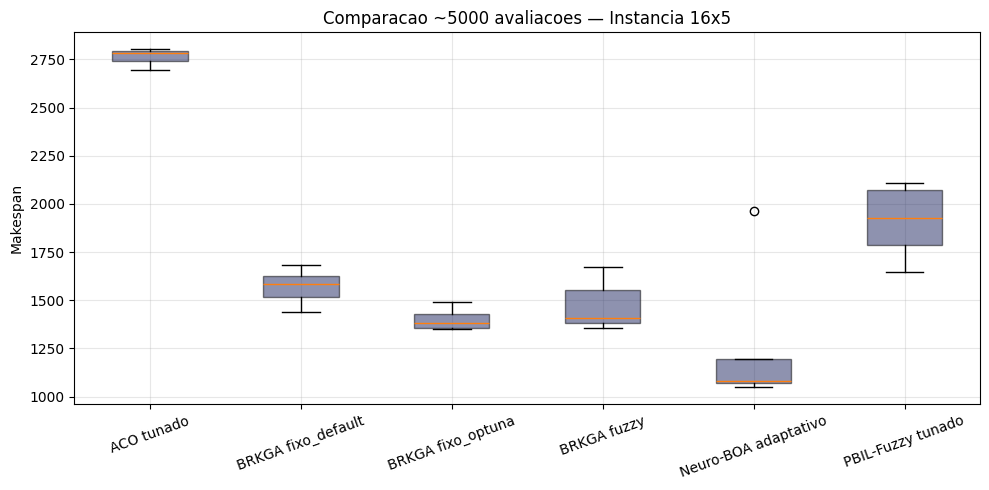

In [20]:
# Boxplot: instancia 16x5
df_alvo = df_v5[df_v5["instancia"] == "16x5"].dropna(subset=["makespan"])
df_alvo["rotulo"] = df_alvo["solver"] + " " + df_alvo["versao"]

solvers_unicos = sorted(df_alvo["rotulo"].unique())
dados = [df_alvo[df_alvo["rotulo"] == s]["makespan"].values for s in solvers_unicos]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(dados, labels=solvers_unicos, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#1E2761")
    patch.set_alpha(0.5)
ax.set_title("Comparacao ~5000 avaliacoes — Instancia 16x5")
ax.set_ylabel("Makespan")
ax.grid(alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(str(RESULTADOS_DIR / "boxplot_v5_16x5.png"), dpi=150)
plt.show()


## 10. BRKGA Aprofundado (500 geracoes)

Com os parametros otimizados pelo Optuna, roda-se o BRKGA por 500 geracoes
para ver o limite da convergencia na instancia alvo 16x5.


In [21]:
N_GEN_500 = 500
N_SEEDS_500 = 10

configs_500 = [
    ("fixo_default", "fixo_default", "#1E2761", {
        "n_elites": 20, "n_offsprings": 70, "n_mutants": 10, "bias": 0.7
    }),
    ("fixo_optuna", "fixo_optuna", "#2C7A57", {
        "n_elites": melhor_config_brkga["n_elites"],
        "n_offsprings": melhor_config_brkga["n_offsprings"],
        "n_mutants": melhor_config_brkga["n_mutants"],
        "bias": melhor_config_brkga["bias"],
    }),
    ("fuzzy", "fuzzy", "#E8871E", {
        "n_elites": melhor_config_brkga["n_elites"],
        "n_offsprings": melhor_config_brkga["n_offsprings"],
        "n_mutants": melhor_config_brkga["n_mutants"],
        "bias": melhor_config_brkga["bias"],
    }),
]

resultados_500 = []
detalhes_500 = {}
total_500 = len(configs_500) * N_SEEDS_500
exec_atual = 0

print(f"BRKGA — {N_GEN_500} geracoes, {N_SEEDS_500} seeds")

for rotulo, version_tag, cor, kwargs in configs_500:
    print(f"\n--- {rotulo} ---")
    for seed in range(100, 100 + N_SEEDS_500):
        exec_atual += 1
        if exec_atual % 5 == 0:
            print(f"  [{exec_atual}/{total_500}] seed {seed}")
        try:
            r = rodar_brkga(engine_alvo, seed=seed, n_gen=N_GEN_500,
                           version=version_tag, **kwargs)
            resultados_500.append({
                "versao": rotulo, "seed": seed,
                "makespan": r.best_cost,
                "tardiness": r.tardiness,
                "gap_pct": round(r.gap_percent(), 2),
                "tempo_s": round(r.time_seconds, 2),
            })
            detalhes_500[(rotulo, seed)] = r
        except Exception as e:
            print(f"    ERRO: {e}")

df_500 = pd.DataFrame(resultados_500)
print("\nConcluido!")


BRKGA — 500 geracoes, 10 seeds

--- fixo_default ---
  [5/30] seed 104
  [10/30] seed 109

--- fixo_optuna ---
  [15/30] seed 104
  [20/30] seed 109

--- fuzzy ---
  [25/30] seed 104
  [30/30] seed 109

Concluido!


In [22]:
print("=" * 70)
print(f"BRKGA — {N_GEN_500} geracoes, instancia 16x5")
print("=" * 70)
for v in df_500["versao"].unique():
    dv = df_500[df_500["versao"] == v]
    mk = dv["makespan"].dropna()
    if len(mk) == 0:
        continue
    print(f"\n{v}:")
    print(f"  Makespan: {mk.mean():.1f} +- {mk.std():.1f}")
    print(f"  Melhor: {mk.min():.1f} | Pior: {mk.max():.1f}")
    print(f"  Tempo: {dv['tempo_s'].mean():.2f}s | Gap: {dv['gap_pct'].mean():.2f}%")


BRKGA — 500 geracoes, instancia 16x5

fixo_default:
  Makespan: 1318.3 +- 58.3
  Melhor: 1247.0 | Pior: 1450.0
  Tempo: 12.41s | Gap: 100.96%

fixo_optuna:
  Makespan: 1218.4 +- 65.1
  Melhor: 1157.0 | Pior: 1343.0
  Tempo: 14.86s | Gap: 85.73%

fuzzy:
  Makespan: 1250.7 +- 73.7
  Melhor: 1109.0 | Pior: 1360.0
  Tempo: 19.88s | Gap: 90.66%


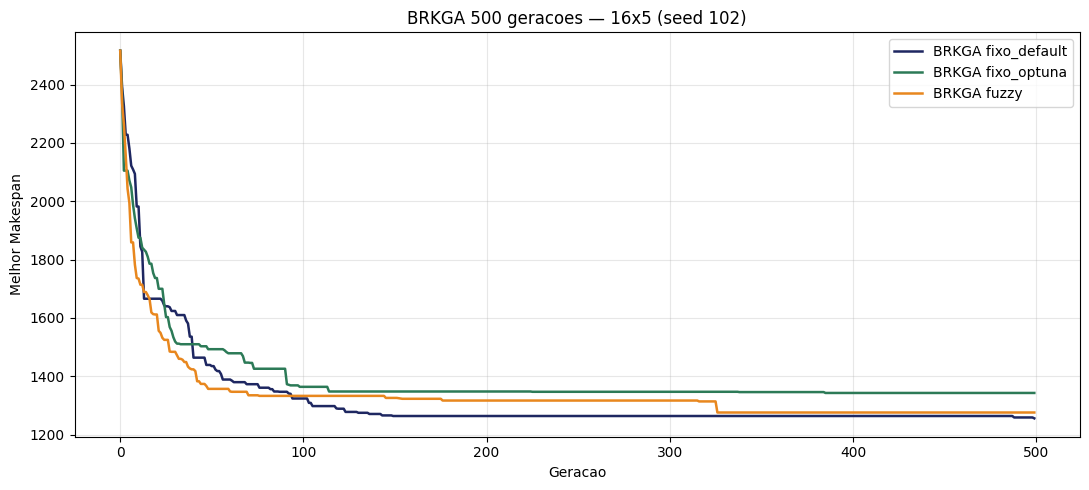

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
cores_500 = {"fixo_default": "#1E2761", "fixo_optuna": "#2C7A57", "fuzzy": "#E8871E"}
seed_plot = 102

for (versao, seed), result in sorted(detalhes_500.items()):
    if seed != seed_plot or not result.history:
        continue
    ax.plot(result.history,
            label=f"BRKGA {versao}",
            color=cores_500.get(versao, "gray"), linewidth=1.8)

ax.set_xlabel("Geracao")
ax.set_ylabel("Melhor Makespan")
ax.set_title(f"BRKGA 500 geracoes — 16x5 (seed {seed_plot})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(RESULTADOS_DIR / "convergencia_brkga_500_v5.png"), dpi=150)
plt.show()


In [24]:
# Pega resultados do experimento padronizado (50 gen) para comparar
df_brkga_pad = pd.concat([df_brkga_def, df_brkga_opt, df_brkga_fuz], ignore_index=True)
df_brkga_pad = df_brkga_pad[df_brkga_pad["instancia"] == "16x5"]

print("\nComparacao 50 vs 500 geracoes (instancia 16x5):")
for v in ["fixo_default", "fixo_optuna", "fuzzy"]:
    mk_50 = df_brkga_pad[df_brkga_pad["versao"] == v]["makespan"].dropna()
    mk_500 = df_500[df_500["versao"] == v]["makespan"].dropna()
    if len(mk_50) == 0 or len(mk_500) == 0:
        continue
    melhoria = mk_50.mean() - mk_500.mean()
    pct = melhoria / mk_50.mean() * 100 if mk_50.mean() > 0 else 0
    print(f"  {v}: ~5k aval={mk_50.mean():.1f} -> 500g={mk_500.mean():.1f} ",
          f"(melhoria de {melhoria:.1f}, {pct:.1f}%)")



Comparacao 50 vs 500 geracoes (instancia 16x5):
  fixo_default: ~5k aval=1569.8 -> 500g=1318.3  (melhoria de 251.5, 16.0%)
  fixo_optuna: ~5k aval=1402.2 -> 500g=1218.4  (melhoria de 183.8, 13.1%)
  fuzzy: ~5k aval=1474.4 -> 500g=1250.7  (melhoria de 223.7, 15.2%)


## 11. Resumo Final


In [25]:
print("=" * 60)
print("RESUMO FINAL — v5")
print("=" * 60)

# Melhor solver por instancia (menor makespan medio)
melhores = df_v5.loc[
    df_v5.groupby("instancia")["makespan"].idxmin()
]
print("\nMelhor makespan medio por instancia:")
for _, r in melhores.iterrows():
    print(f"  {r['instancia']}: {r['solver']} ({r['versao']}) = {r['makespan']:.1f}")

# Solver mais rapido
rapido = df_v5.groupby("solver")["tempo_s"].mean().idxmin()
t = df_v5.groupby("solver")["tempo_s"].mean().min()
print(f"\nSolver mais rapido: {rapido} ({t:.2f}s medio)")

# BRKGA 500 melhoria
print("\nBRKGA 500 geracoes — melhoria em relacao a ~5k aval:")
for v in ["fixo_default", "fixo_optuna", "fuzzy"]:
    mk_50 = df_brkga_pad[df_brkga_pad["versao"] == v]["makespan"].dropna()
    mk_500 = df_500[df_500["versao"] == v]["makespan"].dropna()
    if len(mk_50) == 0 or len(mk_500) == 0:
        continue
    melhoria = mk_50.mean() - mk_500.mean()
    pct = melhoria / mk_50.mean() * 100
    print(f"  {v}: {mk_50.mean():.1f} -> {mk_500.mean():.1f} ({pct:.1f}% melhor)")

print("\nArquivos:")
for f in sorted(RESULTADOS_DIR.glob("*")):
    print(f"  {f.name}")


RESUMO FINAL — v5

Melhor makespan medio por instancia:
  16x2: BRKGA (fixo_optuna) = 987.0
  16x4: Neuro-BOA (adaptativo) = 1187.0
  16x5: Neuro-BOA (adaptativo) = 1049.0
  4x2: BRKGA (fixo_default) = 164.0

Solver mais rapido: PBIL-Fuzzy (0.71s medio)

BRKGA 500 geracoes — melhoria em relacao a ~5k aval:
  fixo_default: 1569.8 -> 1318.3 (16.0% melhor)
  fixo_optuna: 1402.2 -> 1218.4 (13.1% melhor)
  fuzzy: 1474.4 -> 1250.7 (15.2% melhor)

Arquivos:
  boxplot_v5_16x5.png
  convergencia_brkga_500_v5.png
  resultados_v5.csv
